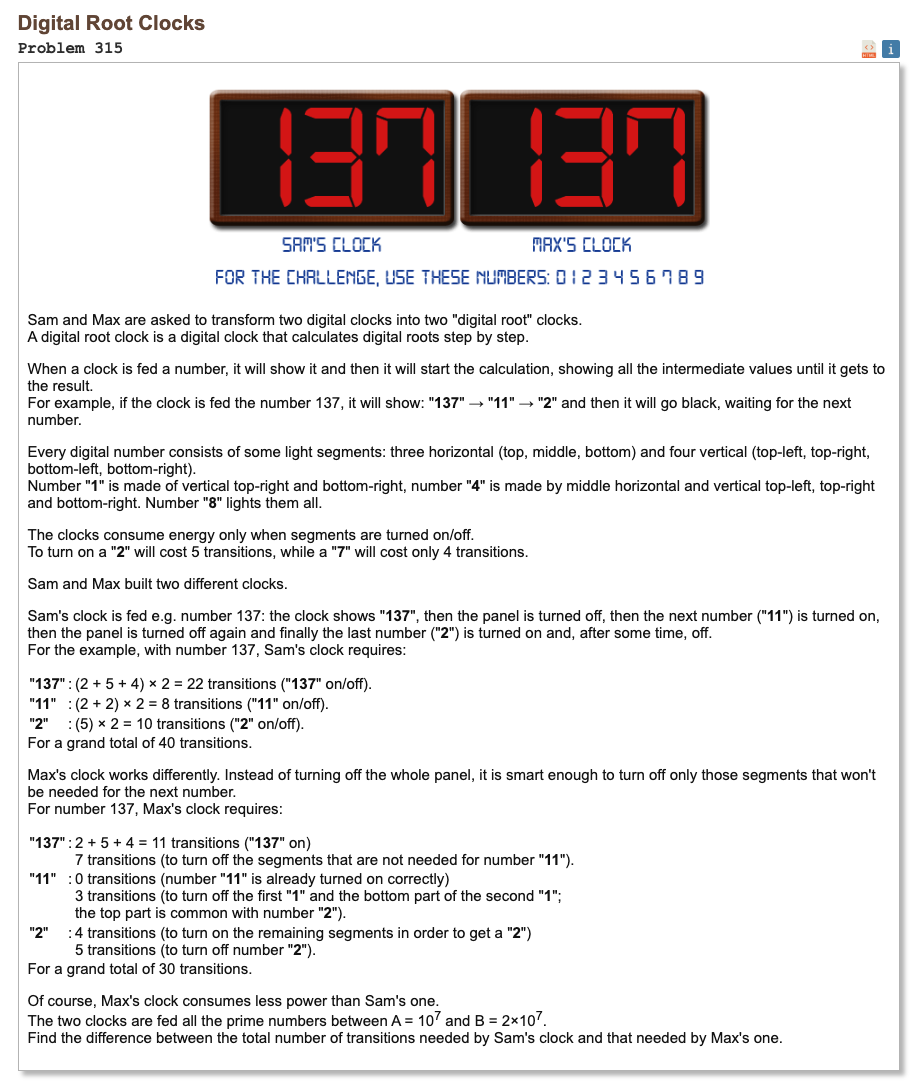

## Initial approach

* generate all primes in the required interval with a sieve
* for each prime, build the digital root chain step by step
* Sam always turns every displayed number fully on and fully off
* Max only pays for changed segments between consecutive displayed numbers
* represent every digit as a seven-segment bitmask
* compare two displayed numbers digit by digit from the right side
* add Sam’s total minus Max’s total for every prime

In [1]:
import math

segments = {
    "0": 0x7e,
    "1": 0x30,
    "2": 0x6d,
    "3": 0x79,
    "4": 0x33,
    "5": 0x5b,
    "6": 0x5f,
    "7": 0x72,
    "8": 0x7f,
    "9": 0x7b
}

segment_count = {digit: segments[digit].bit_count() for digit in segments}

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * limit
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit - 1) + 1):
        if is_prime[p]:
            start = p * p
            is_prime[start:limit:p] = b"\x00" * (((limit - 1 - start) // p) + 1)

    return is_prime

def digit_sum(n):
    total = 0

    while n:
        total += n % 10
        n //= 10

    return total

def digital_root_chain(n):
    values = [n]

    while n >= 10:
        n = digit_sum(n)
        values.append(n)

    return values

def sam_number_cost(n):
    return 2 * sum(segment_count[d] for d in str(n))

def sam_chain_cost(values):
    return sum(sam_number_cost(x) for x in values)

def transition_cost(a, b):
    a = str(a)
    b = str(b)

    total = 0
    i = len(a) - 1
    j = len(b) - 1

    while i >= 0 or j >= 0:
        left = segments[a[i]] if i >= 0 else 0
        right = segments[b[j]] if j >= 0 else 0
        total += (left ^ right).bit_count()

        i -= 1
        j -= 1

    return total

def max_chain_cost(values):
    total = sum(segment_count[d] for d in str(values[0]))

    for i in range(len(values) - 1):
        total += transition_cost(values[i], values[i + 1])

    total += sum(segment_count[d] for d in str(values[-1]))

    return total

def solve():
    start = 10 ** 7
    end = 2 * 10 ** 7

    is_prime = prime_sieve(end)
    result = 0

    for n in range(start, end):
        if is_prime[n]:
            values = digital_root_chain(n)
            result += sam_chain_cost(values) - max_chain_cost(values)

    return result

assert digital_root_chain(137) == [137, 11, 2]
assert sam_chain_cost([137, 11, 2]) == 40
assert max_chain_cost([137, 11, 2]) == 30

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 13625242
CPU times: user 2.5 s, sys: 18.1 ms, total: 2.52 s
Wall time: 2.53 s
